In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from worldcup.tournament import load_teams, get_groups, get_group_matches
from worldcup.simulator import GroupStageSimulator
from worldcup.algorithms.poisson import PoissonGoalModel, _poisson_pmf
from worldcup.algorithms.fifa_rating import FIFARatingModel

sns.set_theme(style='whitegrid', palette='muted')

# ── Configure model here ──────────────────────────────────────────────────────
rating_model = FIFARatingModel(power=0.5)
predictor = PoissonGoalModel(rating_model, base_lambda=1.3, alpha=0.3, max_ratio=10.0)
N_SIMULATIONS = 20_000
SEED = 42
# ─────────────────────────────────────────────────────────────────────────────

teams = load_teams()
groups = get_groups(teams)
flag_map  = {t.name: t.flag  for t in teams}
group_map = {t.name: t.group for t in teams}

# Poisson FIFA rating model

## Algorithm

Instead of predicting outcome probabilities directly, this model assigns each team a **rating** and uses the ratio of those ratings to parameterise two independent Poisson distributions — one for each team's expected goals.

### Step 1 — Rate each team

The `FIFARatingModel` converts FIFA ranking to a strength value using a power transform:

$$r = \frac{1}{\text{ranking}^{p}}$$

With $p = 0.5$ (square root), rank 1 vs rank 2 is a **1.41× ratio** rather than 2×, smoothing the gap at the top while still giving meaningful separation across the full range. Only the *ratio* between two teams matters — the absolute scale is irrelevant.

### Step 2 — Compute expected goals (λ)

For a match between home team $h$ and away team $a$:

$$\text{ratio} = \text{clip}\!\left(\frac{r_h}{r_a},\; \frac{1}{r_{\max}},\; r_{\max}\right)$$

$$\lambda_h = \lambda_0 \cdot \text{ratio}^{\alpha}, \qquad \lambda_a = \frac{\lambda_0}{\text{ratio}^{\alpha}}$$

so $\lambda_h \times \lambda_a = \lambda_0^2$ always — the product is constant regardless of mismatch.

| Parameter | Value | Role |
|---|---|---|
| $\lambda_0$ | 1.3 | Average goals per team per game |
| $\alpha$ | 0.3 | Damping exponent — controls how strongly the rating gap translates into goal difference |
| $r_{\max}$ | 10 | Mismatch cap — no match is modelled as a greater than 10:1 rating advantage |

### Step 3 — Sample goals

$$\text{home goals} \sim \text{Poisson}(\lambda_h), \qquad \text{away goals} \sim \text{Poisson}(\lambda_a)$$

The match outcome (win / draw / loss) is derived directly from the simulated scoreline — no correction step needed.

### Team ratings

In [2]:
rating_rows = [
    {'Team': f"{flag_map[t.name]} {t.name}", 'FIFA ranking': t.fifa_ranking, 'Rating': rating_model.rate(t)}
    for t in sorted(teams, key=lambda t: t.fifa_ranking)[:12]
]
pd.DataFrame(rating_rows).style.hide(axis='index').format({'Rating': '{:.4f}'})

Team,FIFA ranking,Rating
🇦🇷 Argentina,1,1.0000
🇪🇸 Spain,2,0.7071
🇫🇷 France,3,0.5774
🏴󠁧󠁢󠁥󠁮󠁧󠁿 England,4,0.5000
🇵🇹 Portugal,5,0.4472
🇧🇷 Brazil,6,0.4082
🇲🇦 Morocco,7,0.3780
🇳🇱 Netherlands,8,0.3536
🇧🇪 Belgium,9,0.3333
🇩🇪 Germany,10,0.3162


### Example prediction

In [3]:
example_home = next(t for t in teams if t.name == 'Argentina')
example_away = next(t for t in teams if t.name == 'Haiti')

λ_h, λ_a = predictor.lambdas(example_home, example_away)
p_home, p_draw, p_away = predictor.predict(example_home, example_away)

raw_ratio = rating_model.rate(example_home) / rating_model.rate(example_away)
capped_ratio = min(predictor.max_ratio, raw_ratio)
print(f'{example_home.name} (rank {example_home.fifa_ranking})  rating: {rating_model.rate(example_home):.4f}')
print(f'{example_away.name}   (rank {example_away.fifa_ranking})  rating: {rating_model.rate(example_away):.4f}')
print(f'Raw ratio: {raw_ratio:.2f}  →  capped at {capped_ratio:.2f}')
print(f'λ_home = {λ_h:.3f},  λ_away = {λ_a:.3f}')

example_df = pd.DataFrame([
    {'Outcome': f'{example_home.flag} {example_home.name} win', 'Probability': p_home},
    {'Outcome': 'Draw',                                          'Probability': p_draw},
    {'Outcome': f'{example_away.flag} {example_away.name} win', 'Probability': p_away},
])
display(example_df.style.hide(axis='index')
        .format({'Probability': '{:.1%}'})
        .bar(subset='Probability', color='#90CAF9', vmin=0, vmax=1))

Argentina (rank 1)  rating: 1.0000
Haiti   (rank 92)  rating: 0.1043
Raw ratio: 9.59  →  capped at 9.59
λ_home = 2.562,  λ_away = 0.660


Outcome,Probability
🇦🇷 Argentina win,78.4%
Draw,14.2%
🇭🇹 Haiti win,7.4%


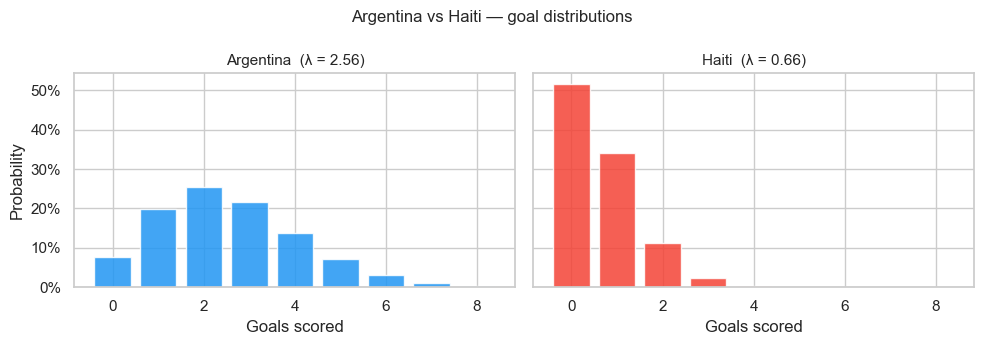

In [4]:
max_g = 8
goals = np.arange(0, max_g + 1)
pmf_h = [_poisson_pmf(g, λ_h) for g in goals]
pmf_a = [_poisson_pmf(g, λ_a) for g in goals]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

axes[0].bar(goals, pmf_h, color='#2196F3', alpha=0.85)
axes[0].set_title(f'{example_home.name}  (λ = {λ_h:.2f})', fontsize=11)
axes[0].set_xlabel('Goals scored')
axes[0].set_ylabel('Probability')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

axes[1].bar(goals, pmf_a, color='#F44336', alpha=0.85)
axes[1].set_title(f'{example_away.name}  (λ = {λ_a:.2f})', fontsize=11)
axes[1].set_xlabel('Goals scored')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

fig.suptitle(f'{example_home.name} vs {example_away.name} — goal distributions', fontsize=12)
plt.tight_layout()
plt.show()

---

## Group stage qualification probabilities

In [5]:
sim = GroupStageSimulator(predictor, n=N_SIMULATIONS, seed=SEED)
results = sim.run(groups)
df = results.to_dataframe()

df['flag']  = df['team'].map(flag_map)
df['group'] = df['team'].map(group_map)
df['Team']  = df['flag'] + ' ' + df['team']

qual_table = df[['group', 'Team', 'p_qualify', 'p_group_winner', 'p_runner_up', 'p_best_third', 'p_eliminated']].copy()
qual_table.columns = ['Group', 'Team', 'Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']

qual_table.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']}) \
    .background_gradient(subset='Qualify',    cmap='RdYlGn',   vmin=0, vmax=1) \
    .background_gradient(subset='Eliminated', cmap='RdYlGn_r', vmin=0, vmax=1)

Group,Team,Qualify,1st,2nd,Best 3rd,Eliminated
J,🇦🇷 Argentina,96.9%,73.2%,18.5%,5.2%,3.1%
H,🇪🇸 Spain,95.1%,65.5%,22.3%,7.3%,4.9%
I,🇫🇷 France,91.6%,56.2%,25.2%,10.2%,8.3%
L,🏴󠁧󠁢󠁥󠁮󠁧󠁿 England,89.7%,50.8%,27.7%,11.2%,10.3%
K,🇵🇹 Portugal,87.7%,48.5%,27.1%,12.1%,12.3%
C,🇧🇷 Brazil,86.9%,42.5%,30.8%,13.6%,13.1%
C,🇲🇦 Morocco,85.7%,38.4%,32.8%,14.6%,14.3%
G,🇧🇪 Belgium,85.2%,43.9%,27.1%,14.2%,14.8%
E,🇩🇪 Germany,85.1%,42.6%,28.0%,14.4%,14.9%
F,🇳🇱 Netherlands,84.3%,42.8%,27.6%,13.9%,15.7%


---

## Match predictions

Analytically derived outcome probabilities for every group stage match.

In [6]:
match_rows = []
for group_name, group_teams in sorted(groups.items()):
    for home, away in get_group_matches(group_teams):
        λ_h, λ_a = predictor.lambdas(home, away)
        p_hw, p_d, p_aw = predictor.predict(home, away)
        match_rows.append({
            'Group':      group_name,
            'Home':       f'{home.flag} {home.name}',
            'Away':       f'{away.flag} {away.name}',
            'λ home':     round(λ_h, 3),
            'λ away':     round(λ_a, 3),
            'Home win %': p_hw,
            'Draw %':     p_d,
            'Away win %': p_aw,
        })

matches_df = pd.DataFrame(match_rows)

matches_df.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Home win %', 'Draw %', 'Away win %']}) \
    .background_gradient(subset='Home win %', cmap='Blues',  vmin=0, vmax=1) \
    .background_gradient(subset='Away win %', cmap='Reds',   vmin=0, vmax=1) \
    .background_gradient(subset='Draw %',     cmap='Greens', vmin=0, vmax=1)

Group,Home,Away,λ home,λ away,Home win %,Draw %,Away win %
A,🇲🇽 Mexico,🇿🇦 South Africa,1.629000,1.037000,51.2%,24.7%,24.1%
A,🇲🇽 Mexico,🇰🇷 South Korea,1.418000,1.192000,42.2%,26.1%,31.6%
A,🇲🇽 Mexico,🇨🇿 Czechia,1.516000,1.115000,46.5%,25.6%,27.9%
A,🇿🇦 South Africa,🇰🇷 South Korea,1.132000,1.493000,28.7%,25.7%,45.5%
A,🇿🇦 South Africa,🇨🇿 Czechia,1.210000,1.397000,32.5%,26.2%,41.3%
A,🇰🇷 South Korea,🇨🇿 Czechia,1.390000,1.216000,40.9%,26.2%,32.8%
B,🇨🇦 Canada,🇧🇦 Bosnia-Herzegovina,1.431000,1.181000,42.8%,26.1%,31.1%
B,🇨🇦 Canada,🇶🇦 Qatar,1.416000,1.194000,42.1%,26.1%,31.7%
B,🇨🇦 Canada,🇨🇭 Switzerland,1.214000,1.392000,32.7%,26.2%,41.1%
B,🇧🇦 Bosnia-Herzegovina,🇶🇦 Qatar,1.286000,1.314000,36.1%,26.4%,37.5%
